SALES & CUSTOMER INSIGHTS DASHBOARD

Original Dataset Shape: (163, 7)

First 5 Rows:
         Date      Customer       Product     Category  Quantity  Unit_Price  \
0  2026-04-13  Manish Kumar      Keyboard  Accessories         5        1800   
1  2026-04-17   Arjun Verma  Office Chair    Furniture         5        8500   
2  2026-04-13   Aditya Jain        Tablet  Electronics         3       22000   
3  2026-03-16   Priya Singh  Office Chair    Furniture         5        8500   
4  2026-04-14   Neha Kapoor  Office Chair    Furniture         3        8500   

   Revenue  
0   9000.0  
1  42500.0  
2  66000.0  
3  42500.0  
4  25500.0  

------------------------------------------------------------
DATA CLEANING
------------------------------------------------------------

Missing Values Before Cleaning:
Date          0
Customer      1
Product       0
Category      1
Quantity      0
Unit_Price    0
Revenue       1
dtype: int64

Duplicate Rows Removed: 3

Missing Values After Cleaning:
Da

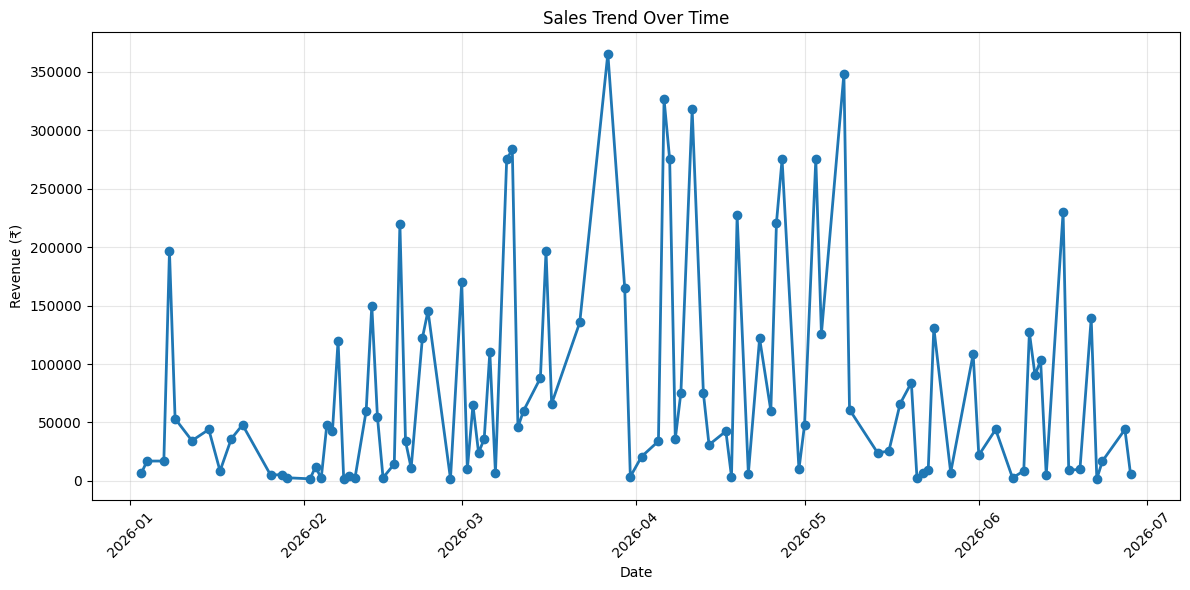

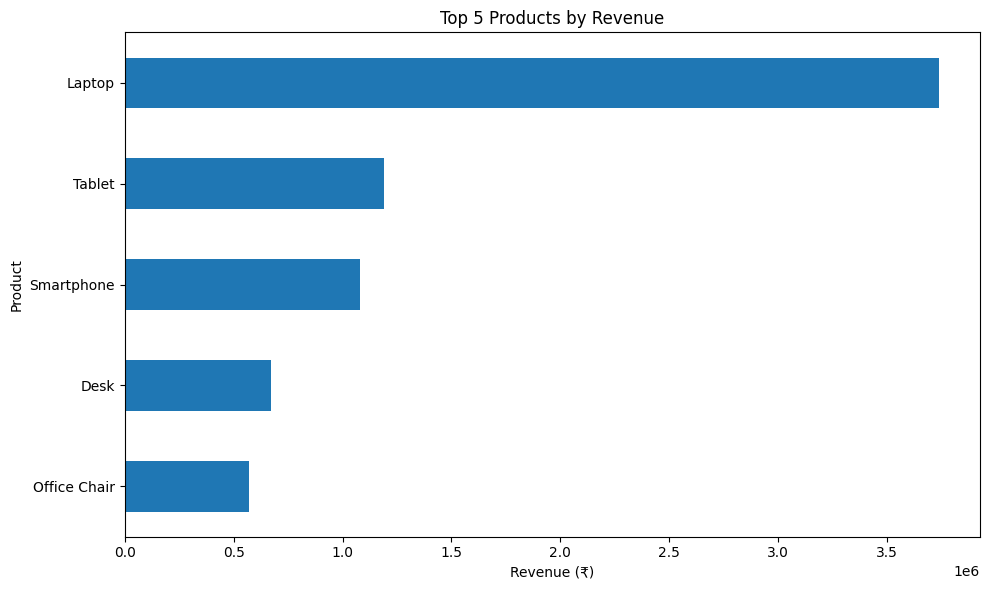

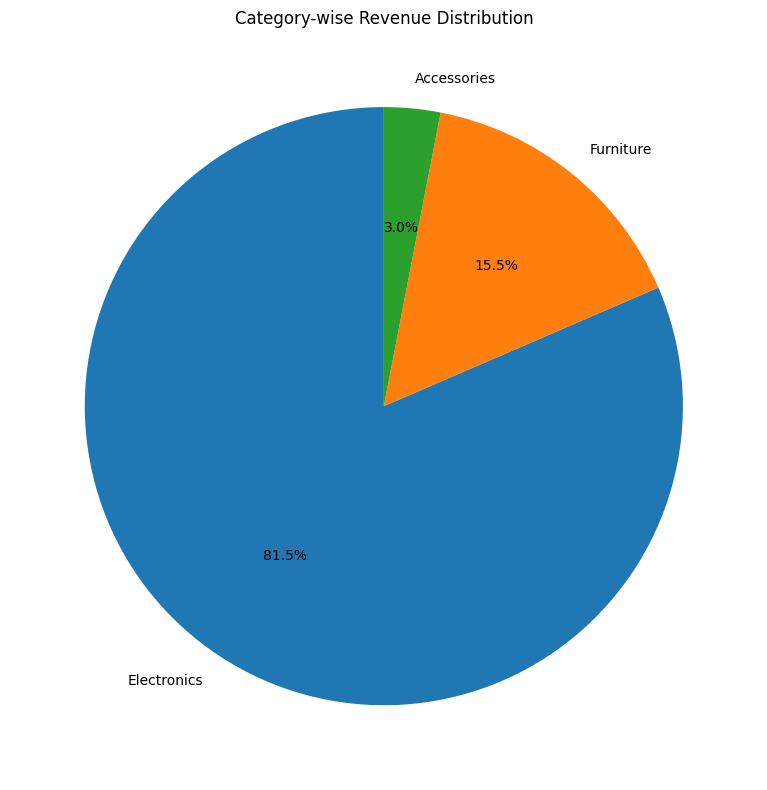


5 BUSINESS INSIGHTS
1. Sneha Agarwal is the highest-value customer, generating ₹1,179,600.00 in revenue.
2. Laptop is the top revenue-generating product, contributing ₹3,740,000.00.
3. Electronics is the leading product category, with revenue of ₹6,497,500.00.
4. The highest single-day revenue was recorded on 27-03-2026, with ₹365,500.00 in sales.
5. The average revenue per transaction is ₹49,831.88, providing a useful indicator of average transaction value.

PROJECT COMPLETED SUCCESSFULLY
Total Transactions: 160
Total Revenue: ₹7,973,100.00
Average Revenue: ₹49,831.88
Top Customer: Sneha Agarwal
Top Product: Laptop
Top Category: Electronics

Charts saved:
- sales_trend.png
- top_products.png
- category_distribution.png


In [1]:
# Day 22 - Sales & Customer Insights Dashboard
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sales_customer_dataset.csv")

print("=" * 60)
print("SALES & CUSTOMER INSIGHTS DASHBOARD")
print("=" * 60)

print("\nOriginal Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\n" + "-" * 60)
print("DATA CLEANING")
print("-" * 60)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()
df["Customer"] = df["Customer"].fillna(df["Customer"].mode()[0])
df["Category"] = df["Category"].fillna(df["Category"].mode()[0])
df["Revenue"] = df["Revenue"].fillna(df["Revenue"].median())
if df["Date"].isnull().any():
    df["Date"] = df["Date"].fillna(df["Date"].mode()[0])

print("\nDuplicate Rows Removed:", duplicate_count)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nCleaned Dataset Shape:", df.shape)

total_sales = df["Revenue"].sum()
average_revenue = df["Revenue"].mean()

print("\n" + "-" * 60)
print("SALES SUMMARY")
print("-" * 60)

print(f"Total Sales / Revenue: ₹{total_sales:,.2f}")
print(f"Average Revenue per Transaction: ₹{average_revenue:,.2f}")

top_customers = (
    df.groupby("Customer")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("\n" + "-" * 60)
print("TOP 5 CUSTOMERS")
print("-" * 60)

print(top_customers)


sales_trend = (
    df.groupby("Date")["Revenue"]
    .sum()
    .sort_index()
)


top_products = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("\n" + "-" * 60)
print("TOP PRODUCTS")
print("-" * 60)

print(top_products)

category_sales = (
    df.groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("\n" + "-" * 60)
print("CATEGORY DISTRIBUTION")
print("-" * 60)

print(category_sales)


plt.figure(figsize=(12, 6))

plt.plot(
    sales_trend.index,
    sales_trend.values,
    marker="o",
    linewidth=2
)

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("sales_trend.png", dpi=300)
plt.show()


plt.figure(figsize=(10, 6))

top_products.head(5).sort_values().plot(
    kind="barh"
)

plt.title("Top 5 Products by Revenue")
plt.xlabel("Revenue (₹)")
plt.ylabel("Product")
plt.tight_layout()

plt.savefig("top_products.png", dpi=300)
plt.show()


plt.figure(figsize=(8, 8))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Category-wise Revenue Distribution")
plt.tight_layout()

plt.savefig("category_distribution.png", dpi=300)
plt.show()


highest_customer = top_customers.index[0]
highest_customer_sales = top_customers.iloc[0]

best_product = top_products.index[0]
best_product_sales = top_products.iloc[0]

best_category = category_sales.index[0]
best_category_sales = category_sales.iloc[0]

best_sales_date = sales_trend.idxmax()
best_sales_day_revenue = sales_trend.max()

print("\n" + "=" * 60)
print("5 BUSINESS INSIGHTS")
print("=" * 60)

print(
    f"1. {highest_customer} is the highest-value customer, "
    f"generating ₹{highest_customer_sales:,.2f} in revenue."
)

print(
    f"2. {best_product} is the top revenue-generating product, "
    f"contributing ₹{best_product_sales:,.2f}."
)

print(
    f"3. {best_category} is the leading product category, "
    f"with revenue of ₹{best_category_sales:,.2f}."
)

print(
    f"4. The highest single-day revenue was recorded on "
    f"{best_sales_date.strftime('%d-%m-%Y')}, "
    f"with ₹{best_sales_day_revenue:,.2f} in sales."
)

print(
    f"5. The average revenue per transaction is "
    f"₹{average_revenue:,.2f}, providing a useful indicator "
    f"of average transaction value."
)


print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"Total Transactions: {len(df)}")
print(f"Total Revenue: ₹{total_sales:,.2f}")
print(f"Average Revenue: ₹{average_revenue:,.2f}")
print(f"Top Customer: {highest_customer}")
print(f"Top Product: {best_product}")
print(f"Top Category: {best_category}")

print("\nCharts saved:")
print("- sales_trend.png")
print("- top_products.png")
print("- category_distribution.png")